# Notebook 06 — Visualizations (2025 BDB)

**Inputs:** `outputs/win_types.csv`, `outputs/player_win_type_summary.csv`, `outputs/edge_rush_player_rankings.csv`  
**Output:** `outputs/figures/` (4 charts)  
**Goal:** Translate the analysis into visuals that tell the story — technique profiles, quadrant positioning, scheme context, and overall rankings.

## Imports & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
OUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load Inputs

All three files are outputs of earlier notebooks — no additional filtering applied here. `win_types.csv` is play-level (20,080 rows), `player_win_type_summary.csv` and `edge_rush_player_rankings.csv` are player-level (108 qualified rushers, ≥ 75 rush attempts).

In [2]:
win_types = pd.read_csv(OUT_DIR / "win_types.csv")
player_summary = pd.read_csv(OUT_DIR / "player_win_type_summary.csv")
rankings = pd.read_csv(OUT_DIR / "edge_rush_player_rankings.csv")

print(win_types.shape)
print(player_summary.shape)
print(rankings.shape)

(20080, 23)
(108, 11)
(108, 19)


## Chart 1 — Technique Profile (Stacked Bar)

Top 30 EDGE rushers by `adjusted_pressure_rate`.  
Each bar shows the proportion of rushes classified as speed / power / counter / loss.  
Sorted by overall effectiveness — reading left to right reveals how elite rushers' technique mixes compare.

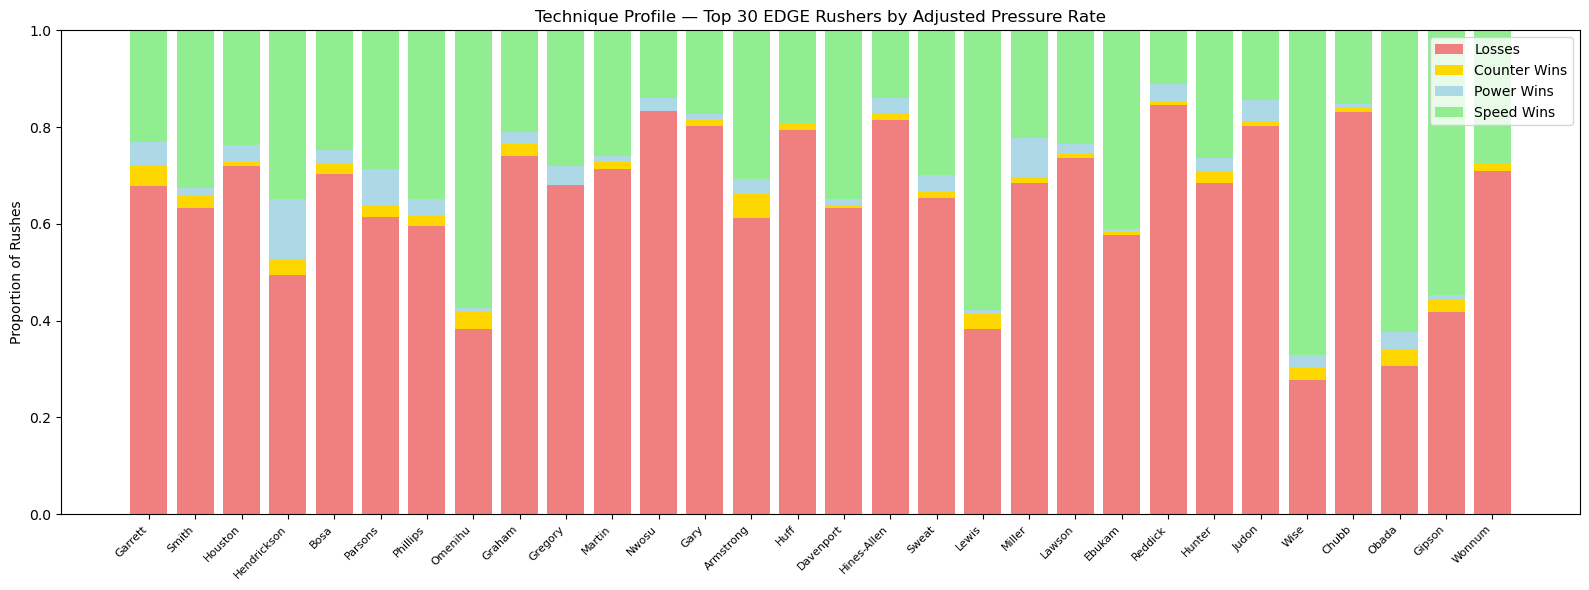

In [3]:
top30 = rankings.head(30).copy()

speed_pct = top30['speed_wins'] / top30['total_rushes']
power_pct = top30['power_wins'] / top30['total_rushes']
counter_pct = top30['counter_wins'] / top30['total_rushes']
loss_pct = top30['losses'] / top30['total_rushes']

labels = top30['displayName'].str.split().str[-1]

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(labels, loss_pct, label='Losses', color='lightcoral')
ax.bar(labels, counter_pct, bottom=loss_pct, label='Counter Wins', color='gold')
ax.bar(labels, power_pct, bottom=loss_pct + counter_pct, label='Power Wins', color='lightblue')
ax.bar(labels, speed_pct, bottom=loss_pct + counter_pct + power_pct, label='Speed Wins', color='lightgreen')
ax.set_ylabel('Proportion of Rushes')
ax.set_title('Technique Profile — Top 30 EDGE Rushers by Adjusted Pressure Rate')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'technique_profile_top_30_edge_rushers.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2 — Speed vs Power Quadrant (Scatter)

x-axis = `speed_index`, y-axis = `power_index`. Reference lines at 1.0 / 1.0 divide the plot into four quadrants:

| Quadrant | Profile |
|---|---|
| Top-right | Versatile — above average at both |
| Top-left | Power specialist |
| Bottom-right | Speed specialist |
| Bottom-left | Neither technique dominant |

Red = scheme priority (double-team rate > 25%). Top 10 players labelled by name.

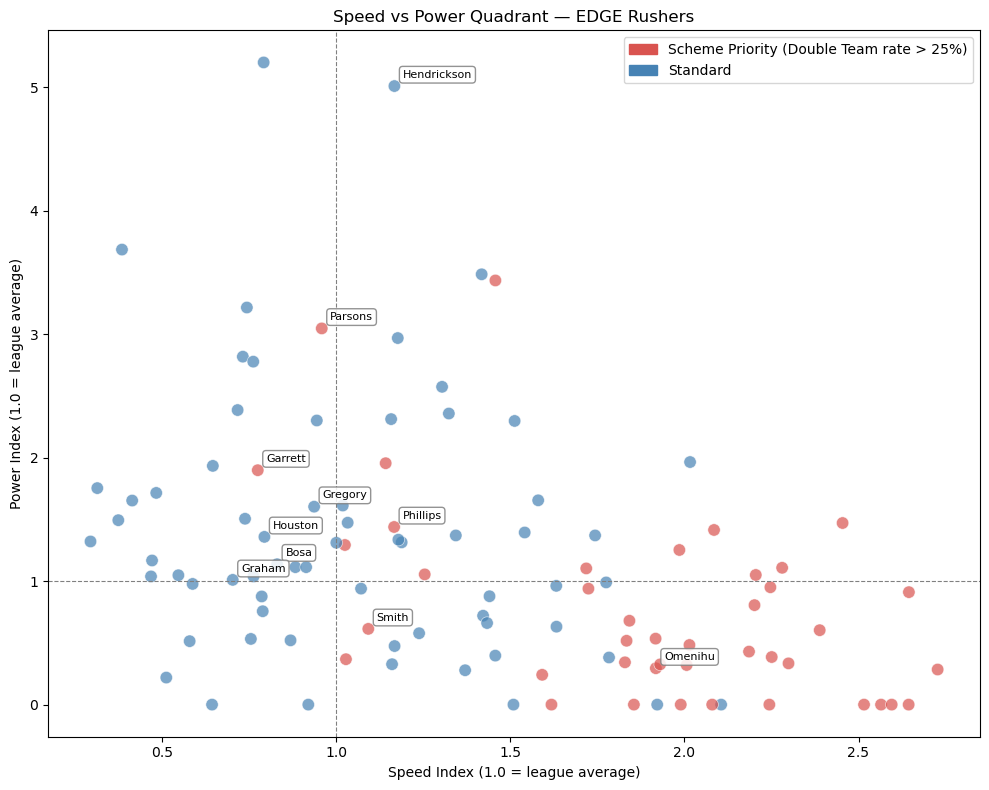

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = rankings['tier'].map({'scheme_priority': '#d9534f', 'standard': 'steelblue'})

ax.scatter(rankings['speed_index'], rankings['power_index'],
           s=80, alpha=0.7, color=colors, edgecolors='white', linewidth=0.5)

ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

top10 = rankings.head(10)
for _, row in top10.iterrows():
    ax.annotate(row['displayName'].split()[-1],
                (row['speed_index'], row['power_index']),
                fontsize=8, ha='left', xytext=(6, 6), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.85))

legend_handles = [
    mpatches.Patch(color='#d9534f', label='Scheme Priority (Double Team rate > 25%)'),
    mpatches.Patch(color='steelblue', label='Standard')
]
ax.legend(handles=legend_handles, loc='upper right')

ax.set_xlabel('Speed Index (1.0 = league average)')
ax.set_ylabel('Power Index (1.0 = league average)')
ax.set_title('Speed vs Power Quadrant — EDGE Rushers')
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb06_chart2_speed_power_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3 — Scheme Priority Players (Double Team Rate)

Top 20 players by `double_team_rate`. A high double-team rate means the offense is spending extra resources to contain this rusher — a form of impact that doesn't always show up in pressure statistics.

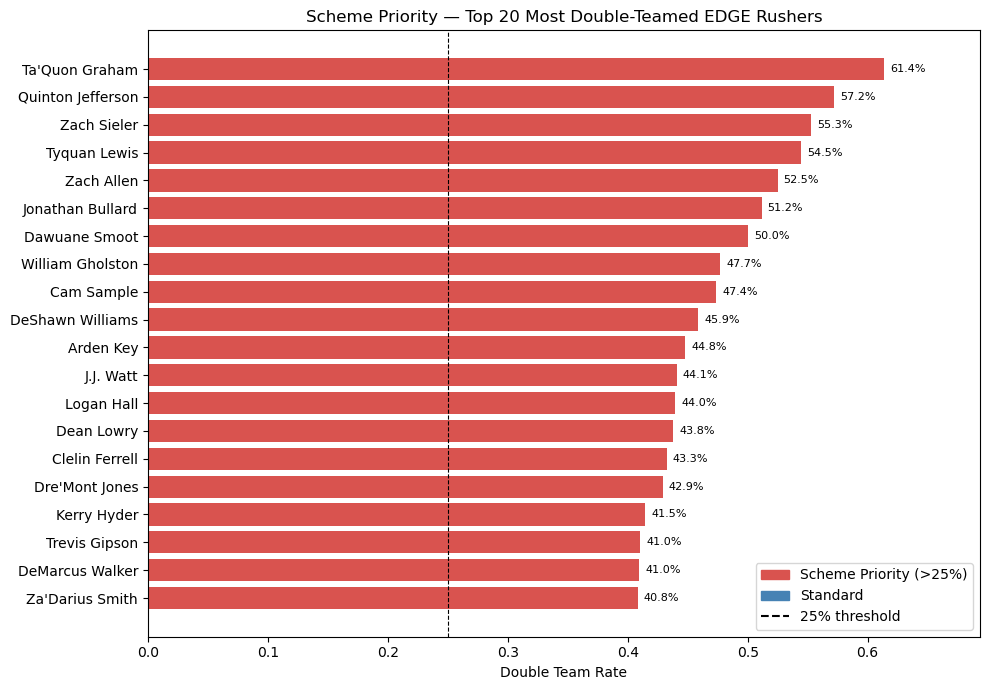

In [10]:
dt_top20 = rankings.sort_values('double_team_rate', ascending=False).head(20).copy()
dt_top20 = dt_top20.sort_values('double_team_rate', ascending=True)

colors = dt_top20['tier'].map({'scheme_priority': '#d9534f', 'standard': 'steelblue'})

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(dt_top20['displayName'], dt_top20['double_team_rate'], color=colors)
ax.axvline(x=0.25, color='black', linestyle='--', linewidth=0.8, label='25% threshold')

for i, (_, row) in enumerate(dt_top20.iterrows()):
    ax.text(row['double_team_rate'] + 0.005, i,
            f"{row['double_team_rate']:.1%}", va='center', fontsize=8)

legend_handles = [
    mpatches.Patch(color='#d9534f', label='Scheme Priority (>25%)'),
    mpatches.Patch(color='steelblue', label='Standard'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='25% threshold')
]
ax.legend(handles=legend_handles, loc='lower right')
ax.set_xlabel('Double Team Rate')
ax.set_title('Scheme Priority — Top 20 Most Double-Teamed EDGE Rushers')
ax.set_xlim(0, dt_top20['double_team_rate'].max() + 0.08)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb06_chart3_double_team_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4 — Overall Rankings (Top 20)

Top 20 EDGE rushers by `adjusted_pressure_rate`.  
Color distinguishes tier: **scheme priority** (double-team rate > 25%) vs **standard**.  
This is the headline output of the entire analysis.

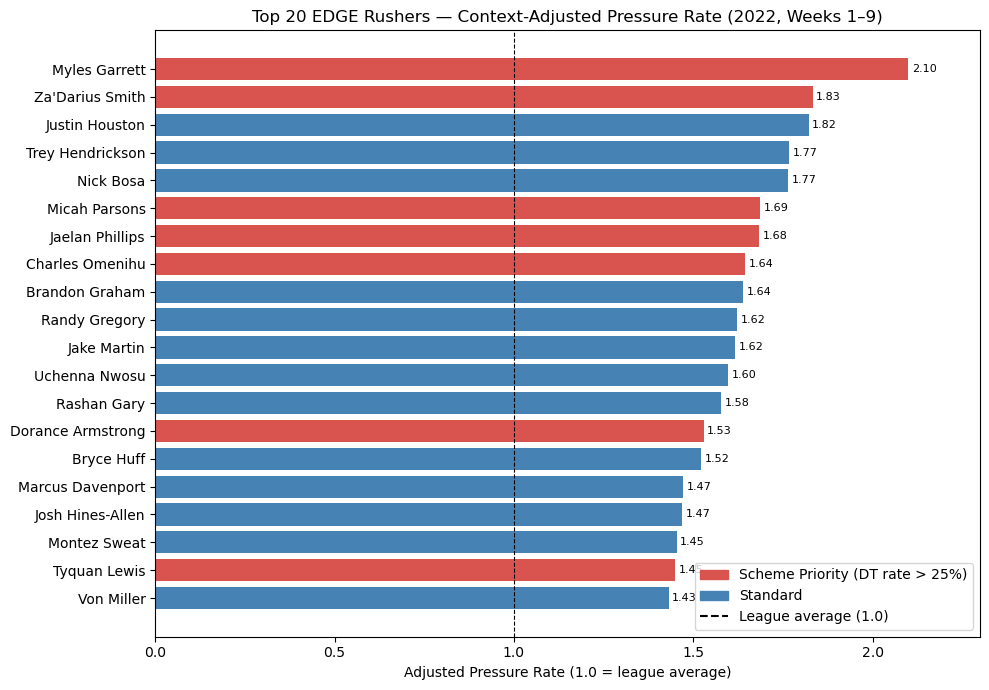

In [11]:
top20 = rankings.head(20).copy()
top20 = top20.sort_values('adjusted_pressure_rate', ascending=True)

colors = top20['tier'].map({'scheme_priority': '#d9534f', 'standard': 'steelblue'})

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(top20['displayName'], top20['adjusted_pressure_rate'], color=colors)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=0.8, label='League average (1.0)')

for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['adjusted_pressure_rate'] + 0.01, i,
            f"{row['adjusted_pressure_rate']:.2f}", va='center', fontsize=8)

legend_handles = [
    mpatches.Patch(color='#d9534f', label='Scheme Priority (DT rate > 25%)'),
    mpatches.Patch(color='steelblue', label='Standard'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='League average (1.0)')
]
ax.legend(handles=legend_handles, loc='lower right')
ax.set_xlabel('Adjusted Pressure Rate (1.0 = league average)')
ax.set_title('Top 20 EDGE Rushers — Context-Adjusted Pressure Rate (2022, Weeks 1–9)')
ax.set_xlim(0, top20['adjusted_pressure_rate'].max() + 0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nb06_chart4_overall_rankings.png', dpi=150, bbox_inches='tight')
plt.show()